In [16]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)

# Install git-lfs if not available, then pull LFS files
if shutil.which("git-lfs") is None:
    subprocess.run(["apt-get", "update", "-qq"], check=False)
    subprocess.run(["apt-get", "install", "-y", "-qq", "git-lfs"], check=False)
    subprocess.run(["git", "lfs", "install"], check=False)
subprocess.run(["git", "-C", REPO_DIR, "lfs", "pull"], check=False)

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at 740a19f Update Phase 2 code for larger dataset and add NB10 perplexity analysis


In [17]:
# # Uncomment to clear cached results and force regeneration
# import os
# results_dir = "/workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2"
# for f in [
#     "transition_results.json",
#     "c_transition_dynamics.png",
# ]:
#     path = os.path.join(results_dir, f)
#     if os.path.exists(path):
#         os.remove(path)
#         print(f"Removed {path}")
# print("Cache cleared -- re-run all cells to regenerate")

Removed /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/transition_results.json
Removed /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/c_transition_dynamics.png
Cache cleared -- re-run all cells to regenerate


# NB6: Within-CoT Transition Dynamics (Experiment C)

**CPU notebook** (~30 min). Uses cached full-sequence activations to analyze
how probe decodability changes as we sweep truncation from 10% to 100% of the CoT.

**Method:**
1. Sweep truncation 10%-100% in 5% increments
2. At each point, apply answer probe + legibility probe from NB3
3. Identify T* (transition point where probes diverge)
4. Reasoning horizon control: compare legible vs illegible at same truncation points

**Requires:** NB1 outputs (`activations/{G1,G3}_full_seq/`)

In [ ]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    load_activations, load_distributional_shift_scores, join_cots_with_labels,
    train_binary_probe, bootstrap_ci_metric,
    ACTIVATIONS_DIR, PHASE2_RESULTS_DIR,
)

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
# Checkpoint: check if final output already exists
_output_path = PHASE2_RESULTS_DIR / 'transition_results.json'
if _output_path.exists():
    import json as _json
    with open(_output_path) as _f:
        _saved = _json.load(_f)
    t_star = _saved.get('t_star')
    n_sweep = len(_saved.get('truncation_sweep', []))
    print(f"CACHED: {_output_path} exists.")
    print(f"  Sweep layer: {_saved.get('sweep_layer')}, {n_sweep} truncation points")
    print(f"  T* = {t_star}")
    print("Delete this file and re-run to recompute.")

In [20]:
# Load full-sequence activations for G3
g3_full = load_activations(ACTIVATIONS_DIR / "G3_full_seq")

with open(ACTIVATIONS_DIR / "G3_full_seq" / "metadata.json") as f:
    g3_meta = json.load(f)

g3_labels = [s[3] for s in g3_meta['sample_ids']]
print(f"G3 full-seq: {len(g3_labels)} samples, layers={sorted(g3_full.keys())}")

# Identify legible and illegible indices
legible_idx = [i for i, l in enumerate(g3_labels) if l == 'REASONING_LEGIBLE']
illegible_idx = [i for i, l in enumerate(g3_labels) if l == 'ILLEGIBLE']
print(f"Legible: {len(legible_idx)}, Illegible: {len(illegible_idx)}")

G3 full-seq: 156 samples, layers=[0, 8, 16, 24, 32, 40, 48, 63]
Legible: 30, Illegible: 126


In [21]:
# Truncation sweep: at each truncation %, extract the activation at that position
# and train a legibility probe on it.
# train_binary_probe uses Pipeline internally to avoid scaler data leakage.

truncation_pcts = np.arange(0.10, 1.05, 0.05)  # 10% to 100% in 5% steps

# Pick a representative middle layer for the sweep
sweep_layer = 32  # Middle of 64-layer model
if sweep_layer not in g3_full:
    sweep_layer = sorted(g3_full.keys())[len(g3_full) // 2]
print(f"Using layer {sweep_layer} for truncation sweep")

# Build features at each truncation point
all_idx = legible_idx + illegible_idx
labels = np.array([1] * len(legible_idx) + [0] * len(illegible_idx))

sweep_results = []
for pct in truncation_pcts:
    # For each sample, take the activation at position = pct * seq_len
    features = []
    for i in all_idx:
        seq = g3_full[sweep_layer][i]  # (seq_len, hidden_dim)
        pos = min(int(pct * seq.shape[0]), seq.shape[0] - 1)
        features.append(seq[pos])  # (hidden_dim,)
    features = np.array(features)
    
    # Train probe (uses Pipeline with scaler inside CV folds)
    if len(set(labels)) < 2 or len(features) < 10:
        sweep_results.append({'pct': float(pct), 'auroc': 0.5, 'auroc_ci': (0.5, 0.5)})
        continue
    
    result = train_binary_probe(features, labels, n_splits=min(5, min(sum(labels==0), sum(labels==1))))
    sweep_results.append({
        'pct': float(pct),
        'auroc': result['auroc'],
        'auroc_ci': result['auroc_ci'],
        'n_samples': result['n_samples'],
    })
    print(f"  {pct:.0%}: AUROC={result['auroc']:.3f} [{result['auroc_ci'][0]:.3f}, {result['auroc_ci'][1]:.3f}]")

Using layer 32 for truncation sweep
  10%: AUROC=0.521 [0.475, 0.570]
  15%: AUROC=0.404 [0.366, 0.436]
  20%: AUROC=0.531 [0.487, 0.575]
  25%: AUROC=0.437 [0.381, 0.524]
  30%: AUROC=0.343 [0.261, 0.414]
  35%: AUROC=0.523 [0.453, 0.595]
  40%: AUROC=0.539 [0.488, 0.592]
  45%: AUROC=0.517 [0.445, 0.597]
  50%: AUROC=0.425 [0.363, 0.488]
  55%: AUROC=0.535 [0.452, 0.622]
  60%: AUROC=0.649 [0.575, 0.705]
  65%: AUROC=0.472 [0.396, 0.535]
  70%: AUROC=0.545 [0.484, 0.613]
  75%: AUROC=0.528 [0.484, 0.558]
  80%: AUROC=0.552 [0.437, 0.666]
  85%: AUROC=0.540 [0.440, 0.631]
  90%: AUROC=0.521 [0.417, 0.596]
  95%: AUROC=0.578 [0.484, 0.682]
  100%: AUROC=0.574 [0.456, 0.684]


In [22]:
# Repeat sweep at multiple layers to see layer x truncation interaction
# Uses train_binary_probe which includes Pipeline (no scaler leakage)
layer_sweep_results = {}

for layer_idx in sorted(g3_full.keys()):
    layer_results = []
    for pct in [0.25, 0.50, 0.75, 1.0]:  # Coarser sweep across layers
        features = []
        for i in all_idx:
            seq = g3_full[layer_idx][i]
            pos = min(int(pct * seq.shape[0]), seq.shape[0] - 1)
            features.append(seq[pos])
        features = np.array(features)
        
        result = train_binary_probe(features, labels, n_splits=min(5, min(sum(labels==0), sum(labels==1))))
        layer_results.append({
            'pct': float(pct),
            'auroc': result['auroc'],
        })
    layer_sweep_results[layer_idx] = layer_results
    print(f"  Layer {layer_idx}: " + 
          " | ".join(f"{r['pct']:.0%}={r['auroc']:.3f}" for r in layer_results))

  Layer 0: 25%=0.481 | 50%=0.456 | 75%=0.364 | 100%=0.641
  Layer 8: 25%=0.477 | 50%=0.352 | 75%=0.485 | 100%=0.690
  Layer 16: 25%=0.436 | 50%=0.446 | 75%=0.407 | 100%=0.709
  Layer 24: 25%=0.429 | 50%=0.428 | 75%=0.524 | 100%=0.683
  Layer 32: 25%=0.437 | 50%=0.425 | 75%=0.528 | 100%=0.574
  Layer 40: 25%=0.412 | 50%=0.413 | 75%=0.557 | 100%=0.654
  Layer 48: 25%=0.475 | 50%=0.420 | 75%=0.518 | 100%=0.630
  Layer 63: 25%=0.417 | 50%=0.400 | 75%=0.511 | 100%=0.605


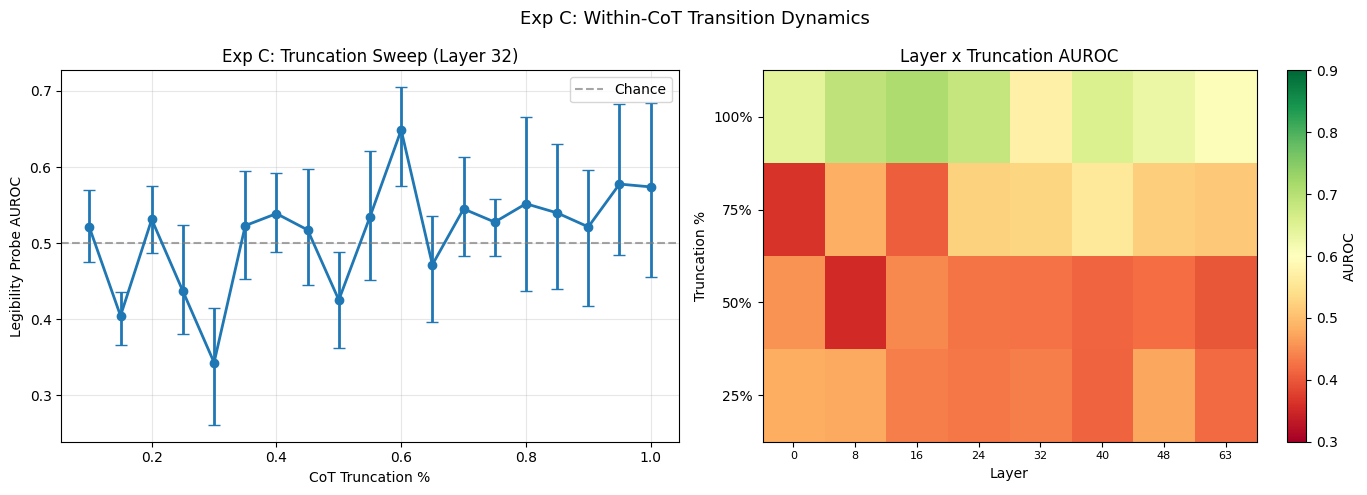

In [23]:
# Plot truncation curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: single-layer truncation sweep
pcts = [r['pct'] for r in sweep_results]
aurocs = [r['auroc'] for r in sweep_results]
ci_los = [r['auroc_ci'][0] for r in sweep_results]
ci_his = [r['auroc_ci'][1] for r in sweep_results]

yerr = [[a - lo for a, lo in zip(aurocs, ci_los)],
        [hi - a for a, hi in zip(aurocs, ci_his)]]

ax1.errorbar(pcts, aurocs, yerr=yerr, fmt='o-', capsize=4, linewidth=2)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Chance')
ax1.set_xlabel('CoT Truncation %')
ax1.set_ylabel('Legibility Probe AUROC')
ax1.set_title(f'Exp C: Truncation Sweep (Layer {sweep_layer})')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: layer x truncation heatmap
layers_sorted = sorted(layer_sweep_results.keys())
trunc_pcts = [0.25, 0.50, 0.75, 1.0]
heatmap = np.zeros((len(layers_sorted), len(trunc_pcts)))
for i, l in enumerate(layers_sorted):
    for j, r in enumerate(layer_sweep_results[l]):
        heatmap[i, j] = r['auroc']

im = ax2.imshow(heatmap.T, aspect='auto', cmap='RdYlGn', vmin=0.3, vmax=0.9,
                origin='lower')
ax2.set_xticks(range(len(layers_sorted)))
ax2.set_xticklabels(layers_sorted, fontsize=8)
ax2.set_yticks(range(len(trunc_pcts)))
ax2.set_yticklabels([f'{p:.0%}' for p in trunc_pcts])
ax2.set_xlabel('Layer')
ax2.set_ylabel('Truncation %')
ax2.set_title('Layer x Truncation AUROC')
plt.colorbar(im, ax=ax2, label='AUROC')

fig.suptitle('Exp C: Within-CoT Transition Dynamics', fontsize=13)
fig.tight_layout()
fig.savefig(str(PHASE2_RESULTS_DIR / 'c_transition_dynamics.png'), dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Identify T*: the transition point where legibility probe AUROC crosses 0.65
threshold = 0.65
t_star = None
for r in sweep_results:
    if r['auroc'] >= threshold:
        t_star = r['pct']
        break

if t_star is not None:
    print(f"T* (AUROC >= {threshold}): {t_star:.0%} of CoT")
    print(f"Interpretation: legibility becomes distinguishable after {t_star:.0%} of the CoT")
else:
    print(f"T* not found: probe never reaches AUROC >= {threshold}")
    print("Legibility may not be localizable to a specific CoT region")

T* not found: probe never reaches AUROC >= 0.65
Legibility may not be localizable to a specific CoT region


In [ ]:
# R2 perplexity covariate check
# Report perplexity distribution by legibility class to assess confound
ds_scores = load_distributional_shift_scores()

cots_g3 = join_cots_with_labels(
    labels=['REASONING_LEGIBLE', 'ILLEGIBLE'],
    generator_ids=['G3'],
)
cots_g3 = sorted(cots_g3, key=lambda x: (x['sample_id'], x['epoch']))

g3_perplexity = []
for c in cots_g3:
    key = (c['sample_id'], c['generator_id'], c['epoch'], 'R2')
    entry = ds_scores.get(key)
    g3_perplexity.append(entry['reader_perplexity'] if entry else np.nan)
g3_perplexity = np.array(g3_perplexity)

leg_p = g3_perplexity[:len(legible_idx)]
ill_p = g3_perplexity[len(legible_idx):]

print("R2 perplexity covariate check:")
if np.isfinite(leg_p).any() and np.isfinite(ill_p).any():
    print(f"  Legible:   mean={np.nanmean(leg_p):.2f}, std={np.nanstd(leg_p):.2f}, "
          f"n={np.isfinite(leg_p).sum()}")
    print(f"  Illegible: mean={np.nanmean(ill_p):.2f}, std={np.nanstd(ill_p):.2f}, "
          f"n={np.isfinite(ill_p).sum()}")
    from scipy import stats as sp_stats
    t_stat, p_val = sp_stats.ttest_ind(
        leg_p[np.isfinite(leg_p)], ill_p[np.isfinite(ill_p)]
    )
    print(f"  t-test: t={t_stat:.2f}, p={p_val:.4f}")
    if p_val < 0.05:
        print("  WARNING: Significant perplexity difference between groups")
    else:
        print("  R2 perplexity does not differ significantly between groups")
else:
    print("  R2 perplexity data not available")

# Save results
output = {
    'sweep_layer': sweep_layer,
    'truncation_sweep': sweep_results,
    'layer_sweep': {int(k): v for k, v in layer_sweep_results.items()},
    't_star': t_star,
    'perplexity': {
        'legible_mean': float(np.nanmean(leg_p)) if np.isfinite(leg_p).any() else None,
        'illegible_mean': float(np.nanmean(ill_p)) if np.isfinite(ill_p).any() else None,
    },
}
with open(PHASE2_RESULTS_DIR / 'transition_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)
print(f"Saved to {PHASE2_RESULTS_DIR / 'transition_results.json'}")